### TO DO
- use 3 models to rate each tweet 

- mean the scores for each tweet

- create bins of [-1, -0.1, 0.1, 1] for neg, neut, pos labels

- plot the categories for each timeline

- If tl2 shows decrease in pos, and also increase in pos in tl3, is the difference statistically meaningful?

In [37]:
# Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from scipy.stats import chi2_contingency, norm
from statsmodels.stats.proportion import proportion_confint
from itertools import combinations

# Persian reshaping
import arabic_reshaper
from bidi.algorithm import get_display

from bidnlp.classification import PersianSentimentAnalyzer

In [17]:
# Reshape
def reshape_persian(text):
    if not isinstance(text, str):
        return text
    reshaped = arabic_reshaper.reshape(text)
    
    return get_display(reshaped)

In [18]:
# Load the dataset
df = pd.read_csv('../data/preprocessed/all_processed.csv', encoding = 'utf-8-sig')
df.head(2)

,message_id,cleaned_text,timeline,normalized,tokens,tokens_persian,tokens_stemmed,final_tokens_freq_stemmed,final_tokens_freq_not_stemmed
0,129507,تنها کسی که تو مملکت داره کارش رو خوب انجام می...,timeline_1,تنها کسی که تو مملکت داره کارش رو خوب انجام می...,"['تنها', 'کسی', 'که', 'تو', 'مملکت', 'داره', '...","['تنها', 'کسی', 'که', 'تو', 'مملکت', 'داره', '...","['تنها', 'کسی', 'که', 'تو', 'مملک', 'داره', 'ک...","['مملک', 'انجا', 'چسب', 'زن', 'الویه', 'نامینو...","['مملکت', 'کارش', 'انجام', 'چسب', 'زن', 'الویه..."
1,129512,اولین سالی که بابانوئل برای بچه‌های ما چیزی آو...,timeline_1,اولین سالی که بابانوئل برای بچه‌های ما چیزی آو...,"['اولین', 'سالی', 'که', 'بابانوئل', 'برای', 'ب...","['اولین', 'سالی', 'که', 'بابانوئل', 'برای', 'ب...","['اولین', 'سال', 'که', 'بابانوئل', 'برا', 'بچه...","['بابانوئل', 'آورد', 'فکر', 'واکن', 'دختر', 'ص...","['سالی', 'بابانوئل', 'بچه\u200cهای', 'آورد', '..."


In [19]:
# Init the model
analyzer = PersianSentimentAnalyzer()
print('Done.')

Done.


In [20]:
# Predict Sentiment for all tweets
texts = df['normalized'].fillna('').tolist()

def batch_analyze(texts, batch_size = 500):
    results = []
    for start in tqdm(range(0, len(texts), batch_size), desc = 'Sentiment'):
        batch = texts[start: start + batch_size]
        batch_results = [analyzer.analyze(t) for t in batch]
        results.extend(batch_results)
    return results

In [26]:
# Analyze 
results = batch_analyze(texts, batch_size = 500)

df['sentiment'] = [r['sentiment'] for r in results]

Sentiment:   0%|          | 0/23 [00:00<?, ?it/s]

In [27]:
# Count and plot
counts = df.groupby(['timeline', 'sentiment']).size().unstack(fill_value = 0)

# Convert to percentage
percentages = counts.div(counts.sum(axis = 1), axis = 0) * 100

print(percentages.round())

sentiment   negative  neutral  positive
timeline                               
timeline_1       5.0     80.0      15.0
timeline_2       5.0     84.0      11.0
timeline_3       6.0     82.0      12.0


In [29]:
# Pct of pos and neg 
totals = df.groupby('timeline').size()

pos_counts = df[df['sentiment'] == 'positive'].groupby('timeline').size()
neg_counts = df[df['sentiment'] == 'negative'].groupby('timeline').size()

# Convert to pct 
pos_pct = (pos_counts / totals * 100).fillna(0)
neg_pct = (neg_counts / totals * 100).fillna(0)

# Build a dataframe
pct_df = pd.DataFrame({
    'Positive (%)': pos_pct,
    'Negative (%)': neg_pct
}).reset_index()

print(pct_df.to_string(index = False))

  timeline  Positive (%)  Negative (%)
timeline_1     15.130458      4.890521
timeline_2     10.681245      5.046257
timeline_3     11.959288      5.555556


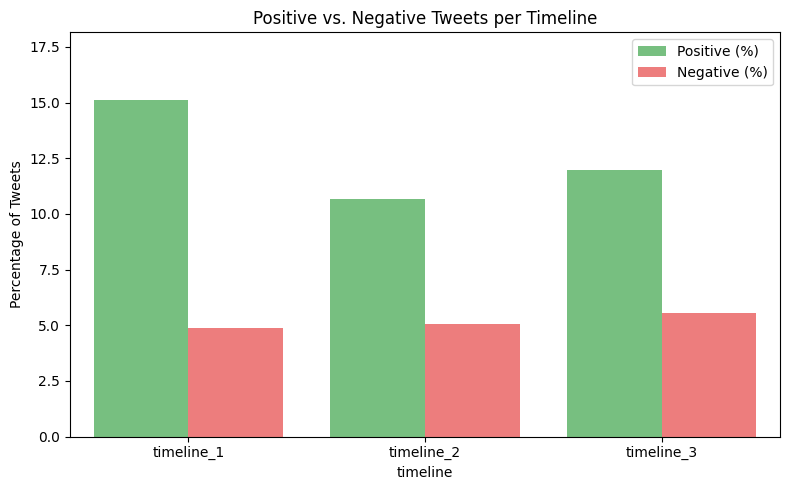

In [31]:
# Plot 
plot_data = pct_df.melt(id_vars = 'timeline', var_name = 'Sentiment', value_name = 'Percentage')

colors = {'Positive (%)': '#6BCB77', 'Negative (%)': '#FF6B6B'}

plt.figure(figsize = (8, 5))

sns.barplot(
    data = plot_data,
    x = 'timeline',
    y = 'Percentage',
    hue = 'Sentiment',
    palette = colors
)

plt.title('Positive vs. Negative Tweets per Timeline')
plt.ylabel('Percentage of Tweets')
plt.ylim(0, max(plot_data['Percentage']) * 1.2)
plt.legend(title = '')
plt.tight_layout()
plt.show()

As shown above, the results align with our hypothesis, there is notable decrease in pos in tl2, and there is a slight increase in tl3 while neg stay relatively the same.

Now we are going to check if the difference is statistically meaningful or just random.

In [33]:
# Create a binary col for pos
df['pos_binary'] = df['sentiment'].apply(lambda x: 'positive' if x == 'positive' else 'not_positive')

# Build contingency table
contingency = pd.crosstab(df['timeline'], df['pos_binary'])
print(contingency, '\n')

pos_binary  not_positive  positive
timeline                          
timeline_1          6473      1154
timeline_2          1062       127
timeline_3          2076       282 



In [35]:
# Chi-square test of independence 
chi2, p, dof, expected = chi2_contingency(contingency)
print(f'Chi-square: {chi2:.2f}')
print(f'P-value: {p:.4f}')

if p < 0.05:
    print('There is a statistically significant difference in positive rates across timelines')
else:
    print('No significant difference')

Chi-square: 27.15
P-value: 0.0000
There is a statistically significant difference in positive rates across timelines


In [39]:
timlines = sorted(df['timeline'].unique())
pairs = list(combinations(timlines, 2))
alpha = 0.05
bonferroni_alpha = alpha / len(pairs)

print(f'Pairwise comparison, a = {bonferroni_alpha:.4f}:')
for t1, t2 in pairs:
    pos1 = contingency.loc[t1, 'positive'] if 'positive' in contingency.columns else 0
    n1 = contingency.loc[t1].sum()
    p1 = pos1 / n1

    pos2 = contingency.loc[t2, 'positive'] if 'positive' in contingency.columns else 0
    n2 = contingency.loc[t2].sum()
    p2 = pos2 / n2

    # Pooled proportion
    p_pool = (pos1 + pos2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    z = (p1 - p2) / se
    p_value_pair = 2 * (1 - norm.cdf(abs(z)))

    significant = 'Significant' if p_value_pair < bonferroni_alpha else 'Not Significant'
    print(f'{t1} (p = {p1:4f}) vs {t2} (p = {p2:.4f}) -> z = {z:.3f}, p = {p_value_pair:.4} {significant}')

Pairwise comparison, a = 0.0167:
timeline_1 (p = 0.151305) vs timeline_2 (p = 0.1068) -> z = 4.049, p = 5.139e-05 Significant
timeline_1 (p = 0.151305) vs timeline_3 (p = 0.1196) -> z = 3.835, p = 0.0001254 Significant
timeline_2 (p = 0.106812) vs timeline_3 (p = 0.1196) -> z = -1.125, p = 0.2606 Not Significant
